In [6]:
def f(x):
    pers = "x - cos(x)"
    return eval(pers, {"x":x, "cos": cos, "sin": sin})

In [16]:
df(0)

1.0

In [53]:
# eps = 1e-6
eps = 1e-14 # 14-digits estimation 

In [18]:
from math import cos, sin

# Fungsi rumus Newton Raphson
def newtonRaph(pers, x0, eps):
    # Terjemahkan input persamaan dari user ke dalam fungsi f(x)
    def f(x):
        return eval(pers, {"x":x, "cos": cos, "sin": sin})

    # Turunan menggunakan numerical approximation
    def df(x, h=1e-6):
        return (f(x+h) - f(x-h)) / (2*h)
    
    x_old = x0 # simpan x0 sebagai x_old
    i = 0
    print("x" + str(i) + " = " + str(x0)) # cetak x0

    # Lakukan iterasi untuk xi
    while True:
        i = i+1 # hitung iterasi
        xi = x_old - (f(x_old) / df(x_old)) # hitung xi baru
        print("x" + str(i) + " = " + str(xi)) # cetak akar ke-i
        Er = abs(xi - x_old) # perbarui galat

        # Cek apakah galat sudah di bawah epsilon
        if Er < eps:
            break
        # Jika belum, jadikan xi sebagai x_old
        # repeat iterasi
        x_old = xi
    
    print("======================")
    print("Hampiran akar x = " + str(xi) + " pada iterasi ke-" + str(i))

# --- Interactive part ---
pers = input("Masukkan persamaan x (contoh, 'x - cos(x)'): ")
x0 = float(input("Masukkan nilai awal x0: "))
eps = float(input("Masukkan galat epsilon (contoh, 1e-6): "))

# Panggil Fungsi
newtonRaph(pers, x0, eps)

Masukkan persamaan x (contoh, 'x - cos(x)'):  x - cos(x)
Masukkan nilai awal x0:  0.6
Masukkan galat epsilon (contoh, 1e-6):  1e-14


x0 = 0.6
x1 = 0.7440173194388235
x2 = 0.7390904768862467
x3 = 0.7390851332214657
x4 = 0.7390851332151606
x5 = 0.7390851332151607
Hampiran akar x = 0.7390851332151607 pada iterasi ke-5


In [63]:
def Secant (x1, x0):
  x2 = x1 - (f(x1) / (f(x1) - f(x0))) * (x1 - x0)
  return x2

In [68]:
x0 = 0.6
x1 = 0.8
# x0 = 1  # Masukan initial value x0 disini
# x1 = 1.5 # Masukan value x1 disini

x_oldbanget = x0
x_old = x1
xi = 0
i = 0

print("x" + str(k) + " = " + str(x0))
print("x" + str(++k) + " = " + str(x1))
# Er = abs(x1-x0)
# print("Er = " + str(Er))

while True:
    i = i+1
    xi = Secant(x_old, x_oldbanget)
    print("x" + str(i) + " = " + str(xi))
    Er = abs(xi-x_old)

    if Er <= eps:
        break
    x_oldbanget = x_old
    x_old = xi

print("======================")
print("Hampiran akar x = " + str(xi) + " pada iterasi ke-" + str(i))

x0 = 0.6
x0 = 0.8
x1 = 0.7371368197353012
x2 = 0.7390597295010554
x3 = 0.739085144155111
x4 = 0.7390851332150993
x5 = 0.7390851332151607
x6 = 0.7390851332151607
Hampiran akar x = 0.7390851332151607 pada iterasi ke-6


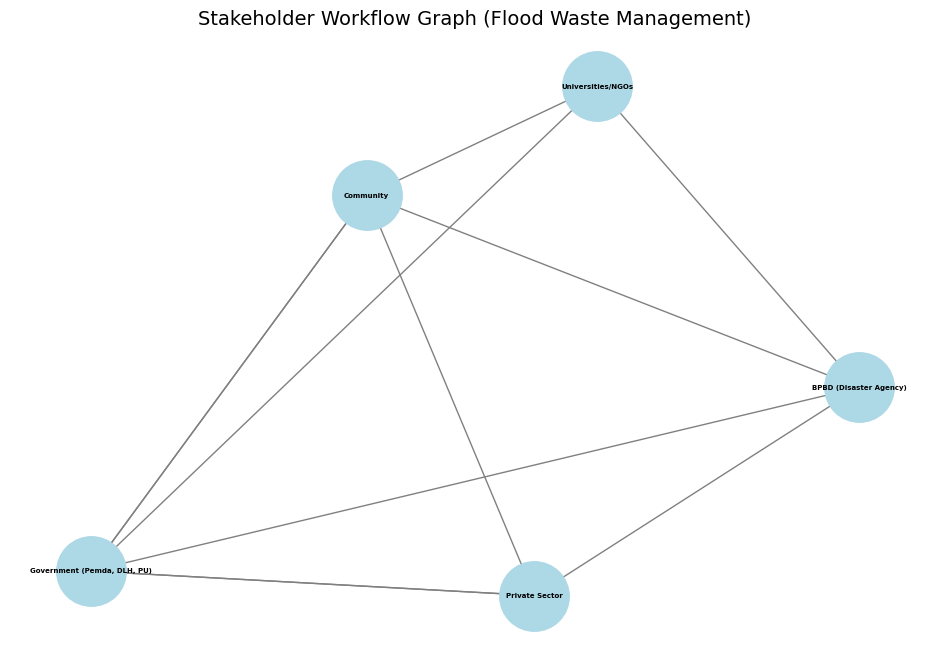

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

# Define stakeholders
stakeholders = [
    "Government (Pemda, DLH, PU)",
    "BPBD (Disaster Agency)",
    "Community",
    "Private Sector",
    "Universities/NGOs"
]

# Define workflow connections (arrows)
connections = [
    # Flood detected
    ("Community", "BPBD (Disaster Agency)"),
    ("BPBD (Disaster Agency)", "Government (Pemda, DLH, PU)"),
    ("Government (Pemda, DLH, PU)", "Private Sector"),
    ("Universities/NGOs", "Government (Pemda, DLH, PU)"),

    # Deployment
    ("BPBD (Disaster Agency)", "Government (Pemda, DLH, PU)"),
    ("Government (Pemda, DLH, PU)", "Private Sector"),
    ("Private Sector", "Community"),
    ("Universities/NGOs", "BPBD (Disaster Agency)"),

    # Operation
    ("Community", "Government (Pemda, DLH, PU)"),
    ("Government (Pemda, DLH, PU)", "Private Sector"),
    ("Private Sector", "BPBD (Disaster Agency)"),
    ("Universities/NGOs", "Government (Pemda, DLH, PU)"),

    # Data sharing
    ("BPBD (Disaster Agency)", "Government (Pemda, DLH, PU)"),
    ("Government (Pemda, DLH, PU)", "Community"),
    ("Private Sector", "Government (Pemda, DLH, PU)"),
    ("Universities/NGOs", "Government (Pemda, DLH, PU)"),

    # Review
    ("BPBD (Disaster Agency)", "Government (Pemda, DLH, PU)"),
    ("Government (Pemda, DLH, PU)", "Private Sector"),
    ("Private Sector", "Government (Pemda, DLH, PU)"),
    ("Community", "BPBD (Disaster Agency)"),
    ("Universities/NGOs", "Government (Pemda, DLH, PU)"),

    # Adaptation
    ("BPBD (Disaster Agency)", "Government (Pemda, DLH, PU)"),
    ("Government (Pemda, DLH, PU)", "Private Sector"),
    ("Community", "Universities/NGOs"),
    ("Universities/NGOs", "Government (Pemda, DLH, PU)")
]

# Build graph
G = nx.DiGraph()
G.add_nodes_from(stakeholders)
G.add_edges_from(connections)

# Draw graph
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)  # Layout for clarity
nx.draw_networkx_nodes(G, pos, node_size=2500, node_color="lightblue")
nx.draw_networkx_edges(G, pos, arrowstyle="->", arrowsize=20, edge_color="gray")
nx.draw_networkx_labels(G, pos, font_size=5, font_weight="bold")

plt.title("Stakeholder Workflow Graph (Flood Waste Management)", fontsize=14)
plt.axis("off")
plt.show()


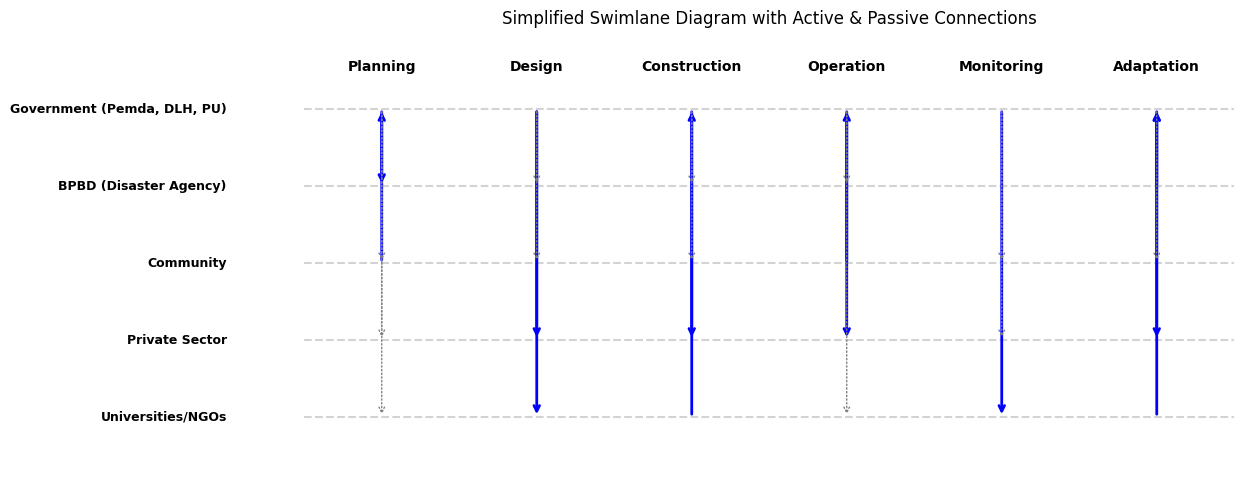

In [5]:
import matplotlib.pyplot as plt

# Stakeholders (lanes)
stakeholders = [
    "Government (Pemda, DLH, PU)",
    "BPBD (Disaster Agency)",
    "Community",
    "Private Sector",
    "Universities/NGOs"
]

# Events (columns)
events = ["Planning", "Design", "Construction", "Operation", "Monitoring", "Adaptation"]

# Active connections (solid arrows)
active_connections = {
    "Planning": [("Community", "Government (Pemda, DLH, PU)"),
                 ("Government (Pemda, DLH, PU)", "BPBD (Disaster Agency)")],
    "Design": [("Government (Pemda, DLH, PU)", "Universities/NGOs"),
               ("Government (Pemda, DLH, PU)", "Private Sector")],
    "Construction": [("Government (Pemda, DLH, PU)", "Private Sector"),
                     ("Universities/NGOs", "Government (Pemda, DLH, PU)")],
    "Operation": [("Community", "Government (Pemda, DLH, PU)"),
                  ("Government (Pemda, DLH, PU)", "Private Sector")],
    "Monitoring": [("Government (Pemda, DLH, PU)", "Universities/NGOs")],
    "Adaptation": [("BPBD (Disaster Agency)", "Government (Pemda, DLH, PU)"),
                   ("Government (Pemda, DLH, PU)", "Private Sector"),
                   ("Universities/NGOs", "Government (Pemda, DLH, PU)")]
}

# Passive notifications (dotted arrows)
passive_connections = {
    "Planning": [("Government (Pemda, DLH, PU)", "Community"),
                 ("Government (Pemda, DLH, PU)", "Private Sector"),
                 ("Government (Pemda, DLH, PU)", "Universities/NGOs")],
    "Design": [("Government (Pemda, DLH, PU)", "BPBD (Disaster Agency)"),
               ("Government (Pemda, DLH, PU)", "Community")],
    "Construction": [("Government (Pemda, DLH, PU)", "BPBD (Disaster Agency)"),
                     ("Government (Pemda, DLH, PU)", "Community")],
    "Operation": [("Government (Pemda, DLH, PU)", "BPBD (Disaster Agency)"),
                  ("Government (Pemda, DLH, PU)", "Universities/NGOs")],
    "Monitoring": [("Government (Pemda, DLH, PU)", "Community"),
                   ("Government (Pemda, DLH, PU)", "Private Sector")],
    "Adaptation": [("Government (Pemda, DLH, PU)", "Community")]
}

# Plot setup
fig, ax = plt.subplots(figsize=(12, 6))

# Draw swimlanes
for i, stakeholder in enumerate(stakeholders):
    y = len(stakeholders) - i
    ax.hlines(y, 0, len(events), colors="lightgray", linestyles="dashed")
    ax.text(-0.5, y, stakeholder, va="center", ha="right", fontsize=9, fontweight="bold")

# Place event labels
for j, event in enumerate(events):
    ax.text(j+0.5, len(stakeholders)+0.5, event, ha="center", fontsize=10, fontweight="bold")

# Draw active arrows (solid)
for j, event in enumerate(events):
    if event in active_connections:
        for src, dst in active_connections[event]:
            y_src = len(stakeholders) - stakeholders.index(src)
            y_dst = len(stakeholders) - stakeholders.index(dst)
            ax.annotate("",
                        xy=(j+0.5, y_dst),
                        xytext=(j+0.5, y_src),
                        arrowprops=dict(arrowstyle="->", color="blue", lw=2))

# Draw passive arrows (dotted)
for j, event in enumerate(events):
    if event in passive_connections:
        for src, dst in passive_connections[event]:
            y_src = len(stakeholders) - stakeholders.index(src)
            y_dst = len(stakeholders) - stakeholders.index(dst)
            ax.annotate("",
                        xy=(j+0.5, y_dst),
                        xytext=(j+0.5, y_src),
                        arrowprops=dict(arrowstyle="->", color="gray", lw=1, linestyle="dotted"))

# Clean up plot
ax.set_xlim(0, len(events))
ax.set_ylim(0, len(stakeholders)+1)
ax.axis("off")
plt.title("Simplified Swimlane Diagram with Active & Passive Connections", fontsize=12)
plt.show()
